<a href="https://colab.research.google.com/github/praaanaaal/AIDS_Sem8_RL_PRANALBORSE_221A026/blob/main/RL_Exp_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PRANAL BORSE - 221A026 - 06

##***Markov Decision Process***
---
A Markov decision process (MDP) refers to a stochastic decision-making process that uses a
mathematical framework to model the decision-making of a dynamic system. It is used in scenarios
where the results are either random or controlled by a decision maker, which makes sequential decisions
over time. MDPs evaluate which actions the decision maker should take considering the current state and
environment of the system.
* Probabilistic planning is the discipline that uses known models to accomplish an agent’s goals
and objectives. While doing so, it emphasizes guiding machines or agents to make decisions
while enabling them to learn how to behave to achieve their goals.
* Reinforcement learning allows applications to learn from the feedback the agents receive from
the environment.



**Problem Statement**


---

A recycling robot wanders around in environment to collect empty soda cans. It has a purpose to collect soda cans and recycle them in the nearby dustbin. There are some features on which the robot works such as Low battery and High Battery.

1.   Low Battery - Search, Wait and Recharge
2.   High Battery - Search and Wait



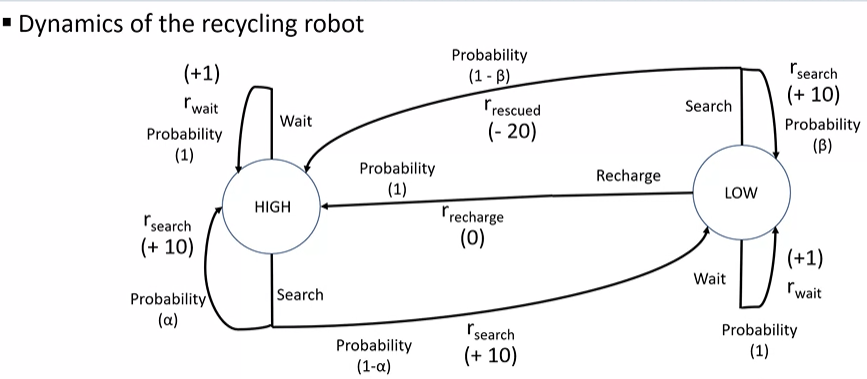

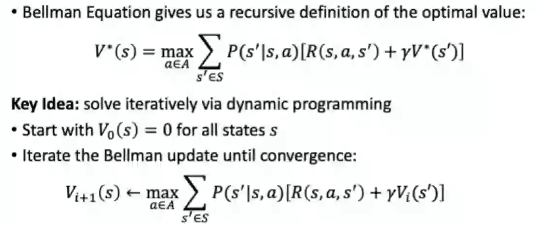

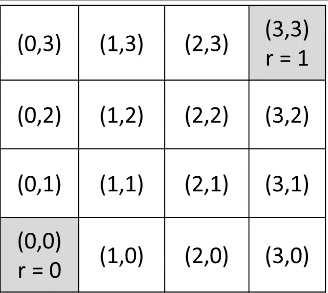

In [1]:
print("PRANAL BORSE - 221A026 - 06")
def value_iteration(states, actions, transtion_model, reward_function, gamma, epsilon):
  #Initialise valuye function
  V = {s: 0 for s in states}

  while True:
    delta = 0
    for s in states:
      v = V[s]
      V[s] = max(sum(transtion_model(s, a, s_prime) *
                    (reward_function(s, a, s_prime) + gamma * V[s_prime])
                    for s_prime in states) for a in actions)
      delta = max(delta, abs(v - V[s]))

    # Check for convergence
    if delta < epsilon:
        break

    # Extract optimal policy
    policy = {}
    for s in states:
      policy[s] = max(actions,
                      key=lambda a: sum(
                          transtion_model(s, a, s_next) *
                          (reward_function(s, a, s_next) + gamma * V[s_next])
                          for s_next in states
                      ))
  return policy, V

PRANAL BORSE - 221A026 - 06


In [2]:
print("PRANAL BORSE - 221A026 - 06")
import numpy as np

PRANAL BORSE - 221A026 - 06


In [3]:
print("PRANAL BORSE - 221A026 - 06")
#Define Grid world Parameters
grid_size = 4
states = [(i, j) for i in range(grid_size) for j in range(grid_size)]
actions = ['up', 'down', 'left', 'right']

PRANAL BORSE - 221A026 - 06


In [4]:
print("PRANAL BORSE - 221A026 - 06")
states

PRANAL BORSE - 221A026 - 06


[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [5]:
print("PRANAL BORSE - 221A026 - 06")
#Define Rewards and Terminal States
rewards = {(0,0): 0, (3,3): 1}
terminal_states = [(0,0), (3,3)]

PRANAL BORSE - 221A026 - 06


In [6]:
print("PRANAL BORSE - 221A026 - 06")
#Transition probabilities
def transition(state, action):
    if state in terminal_states:
        return {state: 1.0}

    i, j = state
    if action == 'up':
        next_state = (max(i - 1, 0), j)
    elif action == 'down':
        next_state = (min(i + 1, grid_size - 1), j)
    elif action == 'left':
        next_state = (i, max(j - 1, 0))
    elif action == 'right':
        next_state = (i, min(j + 1, grid_size - 1))
    else:
        next_state = state # Stay in the same state if action is invalid

    if next_state in terminal_states:
        return {next_state: 1.0}
    else:
        return {next_state: 1.0}

PRANAL BORSE - 221A026 - 06


In [7]:
print("PRANAL BORSE - 221A026 - 06")
# Policy Iteration Algorithm
def policy_iteration(states, actions, gamma=0.9, theta=1e-6):
    policy = {s: np.random.choice(actions) for s in states if s not in terminal_states}
    V = {s: 0 for s in states}

    while True:
        # Policy Evaluation
        while True:
            delta = 0
            for s in states:
                if s in terminal_states:
                    continue
                v = V[s]
                a = policy[s]
                next_states = transition(s, a)
                V[s] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break

        # Policy Improvement
        policy_stable = True
        for s in states:
            if s in terminal_states:
                continue

            old_action = policy[s]
            action_values = {}
            for a in actions:
                next_states = transition(s, a)
                action_values[a] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())

            best_action = max(action_values, key=action_values.get)
            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return policy, V


PRANAL BORSE - 221A026 - 06


In [8]:
print("PRANAL BORSE - 221A026 - 06")
# Run Policy Iteration
policy, V = policy_iteration(states, actions)

# Display Results
print("Optimal Policy:")
for i in range(grid_size):
    print([policy.get((i, j), '-') for j in range(grid_size)])

print("\nState Values:")
for i in range(grid_size):
    print([round(V[(i, j)], 2) for j in range(grid_size)])

PRANAL BORSE - 221A026 - 06
Optimal Policy:
['-', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['right', 'right', 'right', '-']

State Values:
[0, 0.66, 0.73, 0.81]
[0.66, 0.73, 0.81, 0.9]
[0.73, 0.81, 0.9, 1.0]
[0.81, 0.9, 1.0, 0]
